<a href="https://colab.research.google.com/github/luzpereira76/Alura_StoreBR/blob/main/TelecomX_BR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Atividades para realizar nesta primeira etapa:

1. Importar os dados;
2. Compreender quais informações o dataset possui;
3. Verificar as incosistencias;
4. Corrigir as incossistencias;
5. Traduzir as colunas e/ou dados;
6. Criar coluna de contas diarias


#📌 Extracão

In [38]:
import requests
import pandas as pd


In [39]:
URL =  'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/refs/heads/main/TelecomX_Data.json'
response = requests.get(URL)
data = response.json()
df = pd.DataFrame(data)
df.head()


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [40]:
df = pd.json_normalize(data)
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

**VERIFICAÇÕES**

1. Verificando dados unicos

In [42]:
for col in df.columns:
  print(f'{col}: {df[col].unique()}')
  if df[col].nunique() < 50:
    print(df[col].unique())
    print('-' * 50)

customerID: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
Churn: ['No' 'Yes' '']
['No' 'Yes' '']
--------------------------------------------------
customer.gender: ['Female' 'Male']
['Female' 'Male']
--------------------------------------------------
customer.SeniorCitizen: [0 1]
[0 1]
--------------------------------------------------
customer.Partner: ['Yes' 'No']
['Yes' 'No']
--------------------------------------------------
customer.Dependents: ['Yes' 'No']
['Yes' 'No']
--------------------------------------------------
customer.tenure: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
phone.PhoneService: ['Yes' 'No']
['Yes' 'No']
--------------------------------------------------
phone.MultipleLines: ['No' 'Yes' 'No phone service']
['No' 'Yes' 'No phone service']
------

2. Valores Duplicados

In [43]:
print ('Numero de duplicados', df.duplicated().sum())

Numero de duplicados 0


3. Valores Nulos

In [44]:
print ("Numero de Nulos \n", df.isnull().sum())

Numero de Nulos 
 customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


4. Vazio ou em Branco

In [45]:
df.apply(lambda x:x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,224
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


#🔧 Transformação

1. Alterando a coluna 'account.Charges.Total' para float

In [46]:
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

3. Verificação de vazias ou em branco

In [47]:
df.apply(lambda x:x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,224
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [48]:
df = df[df['Churn'].str.strip() != '']
print("Número de filas depois de eliminar as vazias em 'Churn':", len(df))

Número de filas depois de eliminar as vazias em 'Churn': 7043


3. Verificaçao de vazias ou em branco

In [49]:
df.apply(lambda x:x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [50]:
print ("Numero de Nulos \n", df.isnull().sum())

Numero de Nulos 
 customerID                    0
Churn                         0
customer.gender               0
customer.SeniorCitizen        0
customer.Partner              0
customer.Dependents           0
customer.tenure               0
phone.PhoneService            0
phone.MultipleLines           0
internet.InternetService      0
internet.OnlineSecurity       0
internet.OnlineBackup         0
internet.DeviceProtection     0
internet.TechSupport          0
internet.StreamingTV          0
internet.StreamingMovies      0
account.Contract              0
account.PaperlessBilling      0
account.PaymentMethod         0
account.Charges.Monthly       0
account.Charges.Total        11
dtype: int64


In [51]:
df = df.dropna(subset=['account.Charges.Total'])

In [52]:
print ("Numero de Nulos \n", df.isnull().sum())

Numero de Nulos 
 customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


__OPCIONAL

In [53]:
df['contas_diarias'] = df['account.Charges.Monthly'] / 30
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,contas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


___Padronização

In [54]:
colunas = {              # dicioário com o nomes das colunas

     'customerID': 'id',
    'customer.gender': 'genero',
    'customer.SeniorCitizen': 'tem +60',
    'customer.Partner': 'possui_parceiro',
    'customer.Dependents': 'possui_dependentes',
    'customer.tenure': 'tempo_contrato',
    'phone.PhoneService': 'servico_telefone',
    'phone.MultipleLines': 'multiplas_linhas',
    'internet.InternetService': 'tipo_internet',
    'internet.OnlineSecurity': 'seguranca_online',
    'internet.OnlineBackup': 'backup_online',
    'internet.DeviceProtection': 'protecao_dispositivo',
    'internet.TechSupport': 'suporte_tecnico',
    'internet.StreamingTV': 'streaming_tv',
    'internet.StreamingMovies': 'streaming_filmes',
    'account.Contract': 'tipo_contrato',
    'account.PaperlessBilling': 'fatura_digital',
    'account.PaymentMethod': 'metodo_pagamento',
    'account.Charges.Monthly': 'valor_mensal',
    'account.Charges.Total': 'total_cobrado'
}
df = df.rename(columns= colunas)
df

,id,Churn,genero,tem +60,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


___Padrodronizar em Português

In [55]:
df['Churn'] = df['Churn'].replace({'No': 'Não', 'Yes': 'Sim'})
df['genero'] = df['genero'].replace({'Female': 'Feminino', 'Male': 'Masculino'})
df['possui_parceiro'] = df['possui_parceiro'].replace({'Yes': 'Sim', 'No': 'Não'})
df['possui_dependentes'] = df['possui_dependentes'].replace({'Yes': 'Sim', 'No': 'Não'})
df['servico_telefone'] = df['servico_telefone'].replace({'Yes': 'Sim', 'No': 'Não'})
df['multiplas_linhas'] = df['multiplas_linhas'].replace({'No': 'Não', 'Yes': 'Sim', 'No phone service': 'Sem serviço de telefone'})
df['tipo_internet'] = df['tipo_internet'].replace({'DSL': 'DSL', 'Fiber optic': 'Fibra óptica','No': 'Não'})
df.head()

,id,Churn,genero,tem +60,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,0002-ORFBO,Não,Feminino,0,Sim,Sim,9,Sim,Não,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,Não,Masculino,0,Não,Não,9,Sim,Sim,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Sim,Masculino,0,Não,Não,4,Sim,Não,Fibra óptica,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Sim,Masculino,1,Sim,Não,13,Sim,Não,Fibra óptica,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Sim,Feminino,1,Sim,Não,3,Sim,Não,Fibra óptica,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [56]:
columns_to_translate = ['seguranca_online', 'backup_online', 'protecao_dispositivo', 'suporte_tecnico', 'streaming_tv', 'streaming_filmes']
mapping = {'No': 'Não', 'Yes': 'Sim', 'No internet service': 'Sem serviço de internet'}
for col in columns_to_translate:
    df[col] = df[col].replace(mapping)

In [57]:
df['tipo_contrato'] = df['tipo_contrato'].replace({'One year': 'Anual', 'Month-to-month': 'Mensal', 'Two year': 'Bienal'})

In [58]:
df['fatura_digital'] = df['fatura_digital'].replace({'Yes': 'Sim', 'No': 'Não'})

In [59]:
df['metodo_pagamento'] = df['metodo_pagamento'].replace({
    'Mailed check': 'Cheque enviado',
    'Electronic check': 'Cheque eletrônico',
    'Credit card (automatic)': 'Cartão de crédito (automático)',
    'Bank transfer (automatic)': 'Transferência bancária (automática)'
})

In [60]:
df

,id,Churn,genero,tem +60,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,0002-ORFBO,Não,Feminino,0,Sim,Sim,9,Sim,Não,DSL,...,Não,Sim,Sim,Não,Anual,Sim,Cheque enviado,65.60,593.30,2.186667
1,0003-MKNFE,Não,Masculino,0,Não,Não,9,Sim,Sim,DSL,...,Não,Não,Não,Sim,Mensal,Não,Cheque enviado,59.90,542.40,1.996667
2,0004-TLHLJ,Sim,Masculino,0,Não,Não,4,Sim,Não,Fibra óptica,...,Sim,Não,Não,Não,Mensal,Sim,Cheque eletrônico,73.90,280.85,2.463333
3,0011-IGKFF,Sim,Masculino,1,Sim,Não,13,Sim,Não,Fibra óptica,...,Sim,Não,Sim,Sim,Mensal,Sim,Cheque eletrônico,98.00,1237.85,3.266667
4,0013-EXCHZ,Sim,Feminino,1,Sim,Não,3,Sim,Não,Fibra óptica,...,Não,Sim,Sim,Não,Mensal,Sim,Cheque enviado,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,Não,Feminino,0,Não,Não,13,Sim,Não,DSL,...,Não,Sim,Não,Não,Anual,Não,Cheque enviado,55.15,742.90,1.838333
7263,9992-RRAMN,Sim,Masculino,0,Sim,Não,22,Sim,Sim,Fibra óptica,...,Não,Não,Não,Sim,Mensal,Sim,Cheque eletrônico,85.10,1873.70,2.836667
7264,9992-UJOEL,Não,Masculino,0,Não,Não,2,Sim,Não,DSL,...,Não,Não,Não,Não,Mensal,Sim,Cheque enviado,50.30,92.75,1.676667
7265,9993-LHIEB,Não,Masculino,0,Sim,Sim,67,Sim,Não,DSL,...,Sim,Sim,Não,Sim,Bienal,Não,Cheque enviado,67.85,4627.65,2.261667


#📊 Carga e análise

1. Análise Descritiva

In [61]:
df.describe()

,tem +60,tempo_contrato,valor_mensal,total_cobrado,contas_diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,2.159940
std,0.368844,24.545260,30.085974,2266.771362,1.002866
min,0.000000,1.000000,18.250000,18.800000,0.608333
25%,0.000000,9.000000,35.587500,401.450000,1.186250
50%,0.000000,29.000000,70.350000,1397.475000,2.345000
75%,0.000000,55.000000,89.862500,3794.737500,2.995417
max,1.000000,72.000000,118.750000,8684.800000,3.958333


2. Distribuição de Evasão

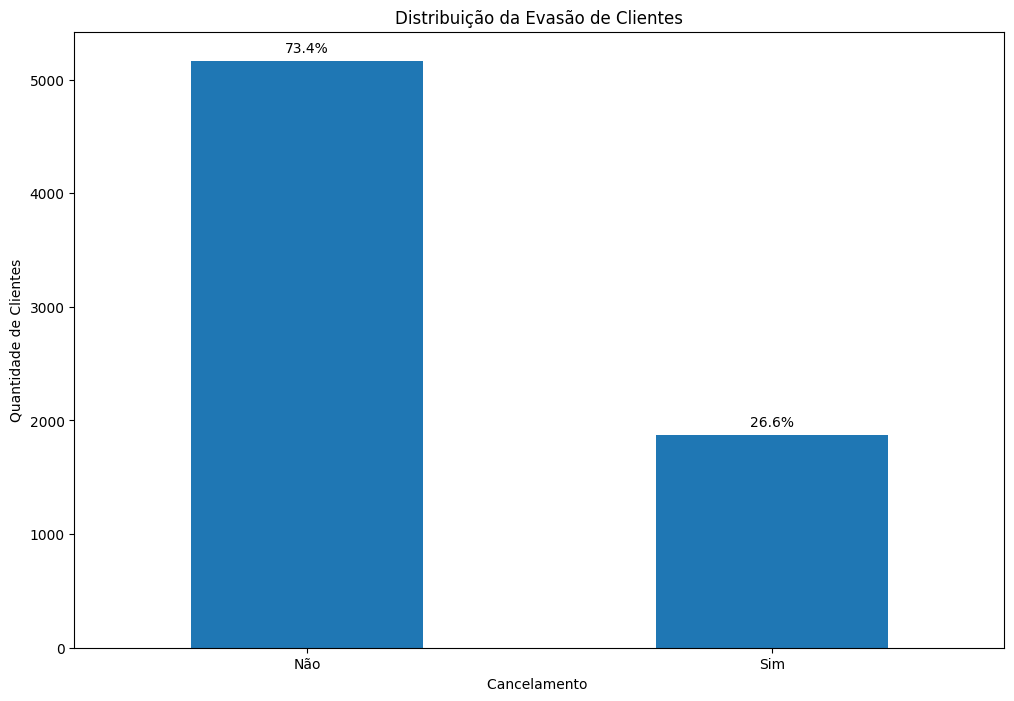

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
churn_counts = df['Churn'].value_counts()
churn_percentages = (churn_counts / len(df)) * 100

ax = churn_counts.plot(kind='bar')
plt.title('Distribuição da Evasão de Clientes')
plt.xlabel('Cancelamento ')
plt.ylabel('Quantidade de Clientes')
plt.xticks(rotation=0)

for i, percentage in enumerate(churn_percentages):
    ax.text(i, churn_counts.iloc[i] + 50, f'{percentage:.1f}%', ha='center', va='bottom')

plt.show()

 3. Distribuição da Evação por Senioridade

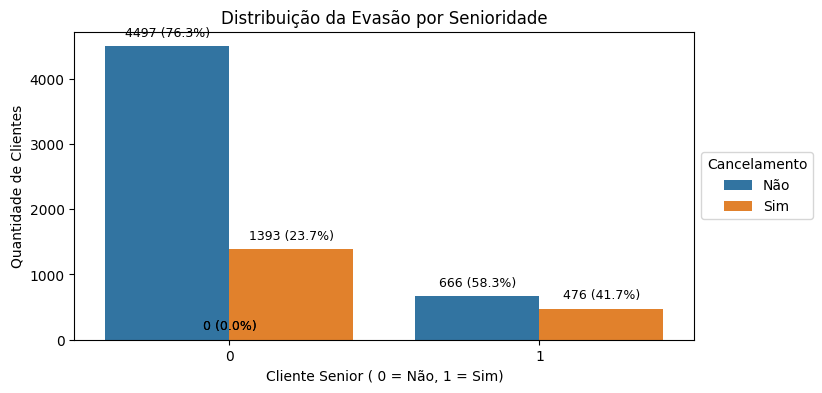

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
ax = sns.countplot(x='tem +60', hue='Churn', data=df)
plt.title('Distribuição da Evasão por Senioridade')
plt.xlabel('Cliente Senior ( 0 = Não, 1 = Sim)')
plt.ylabel('Quantidade de Clientes')
plt.legend(title='Cancelamento',labels=['Não', 'Sim'],
           loc='center left', bbox_to_anchor=(1, 0.5))

# Calculate total counts for each 'tem +60' category
total_seniority_counts = df['tem +60'].value_counts()

# Add annotations with count and percentage
for p in ax.patches:
    height = p.get_height()
    # Determine the 'tem +60' category based on the x-position of the bar
    # The x-axis labels are typically at 0 and 1 for 0 and 1 respectively.
    # We need to map the bar's x-coordinate to the category label.
    x_category = int(round(p.get_x() + p.get_width() / 2))

    # Get the total count for the current 'tem +60' category
    total = total_seniority_counts.get(x_category, 0)

    if total > 0:
        percentage = (height / total) * 100
        annotation_text = f'{int(height)} ({percentage:.1f}%)'
    else:
        annotation_text = str(int(height))

    ax.annotate(annotation_text,
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

4. Contagem de Evasão por Variáveis Categóricas

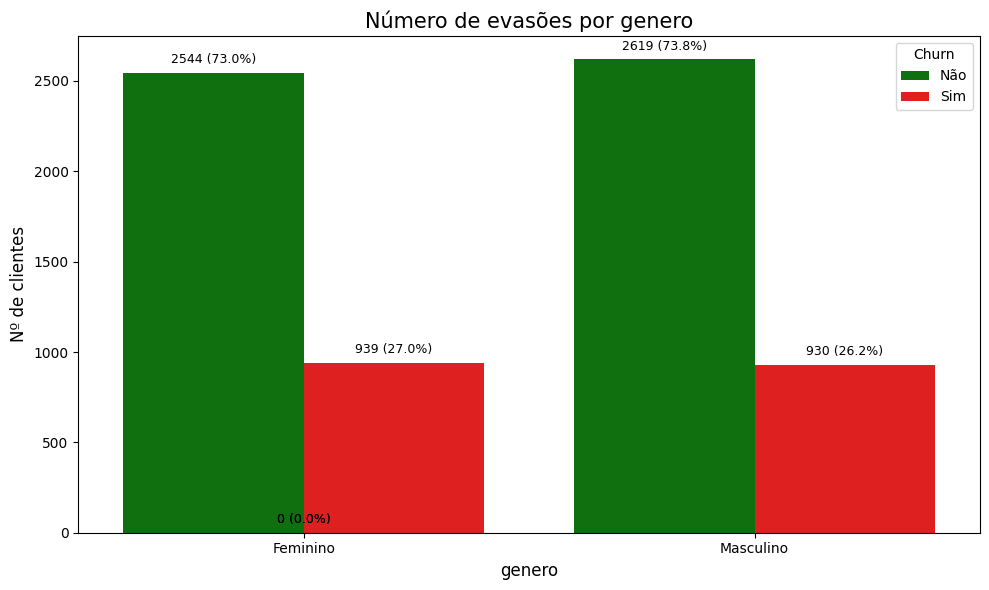

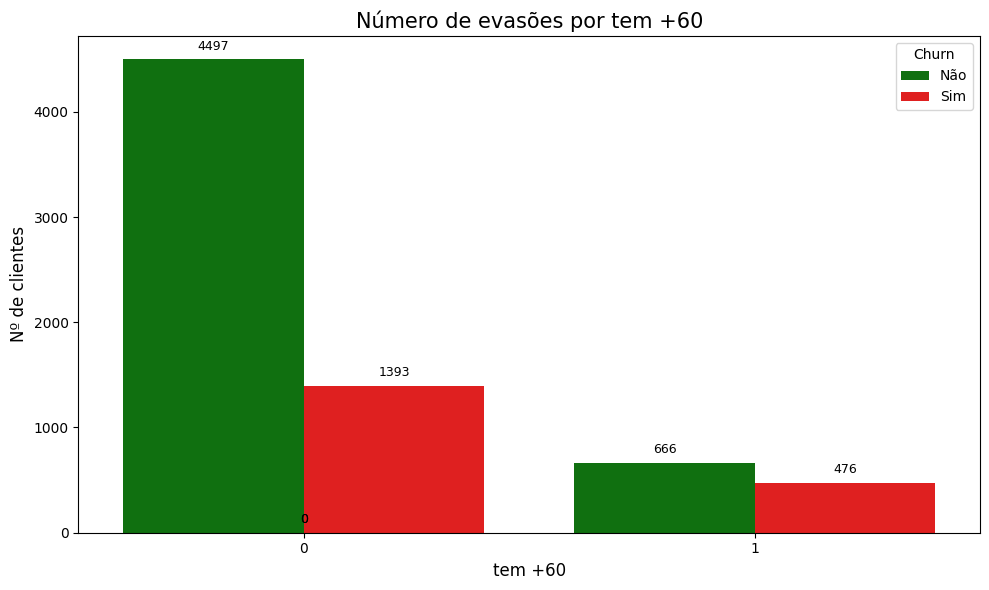

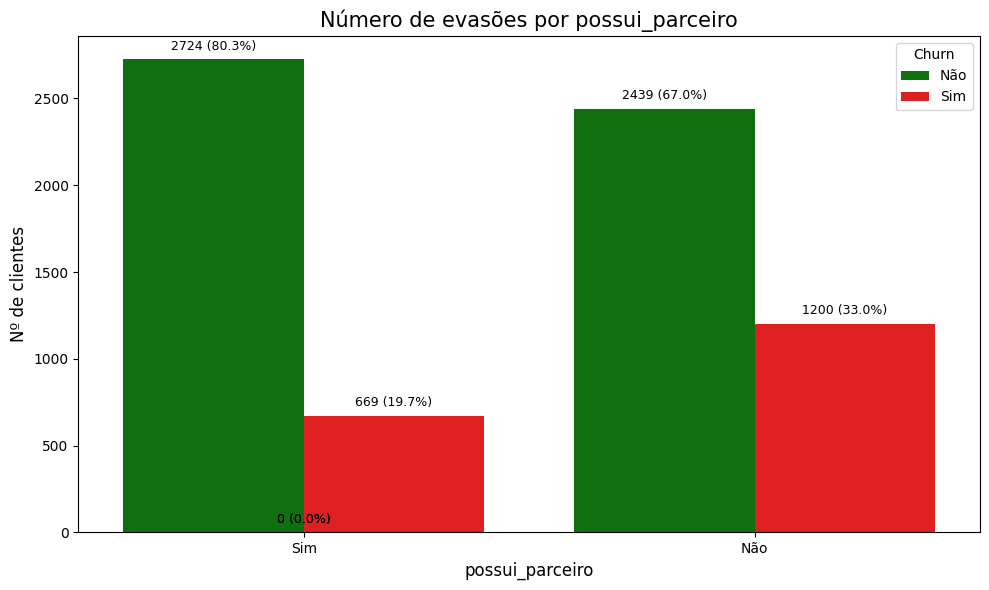

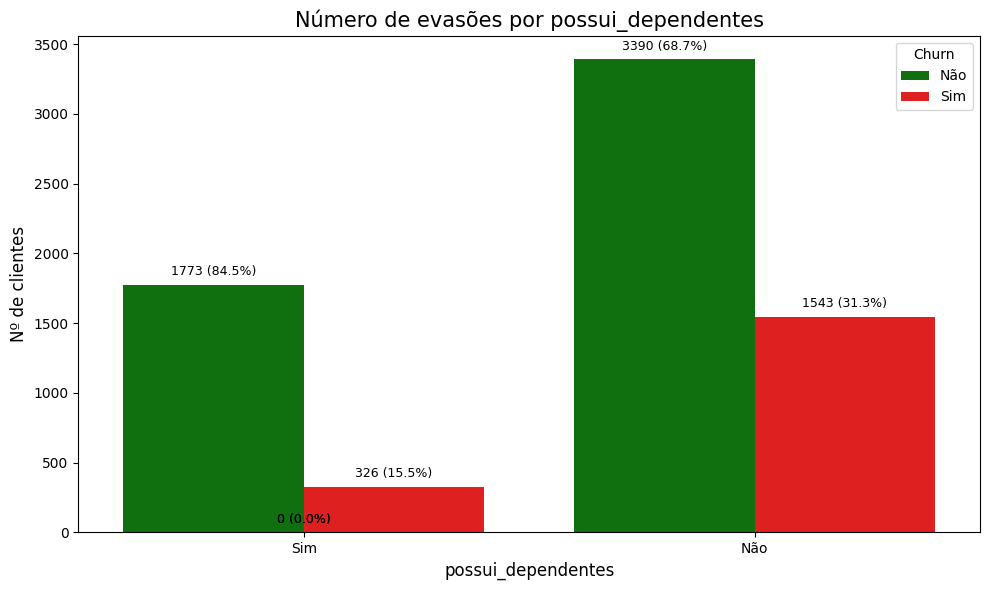

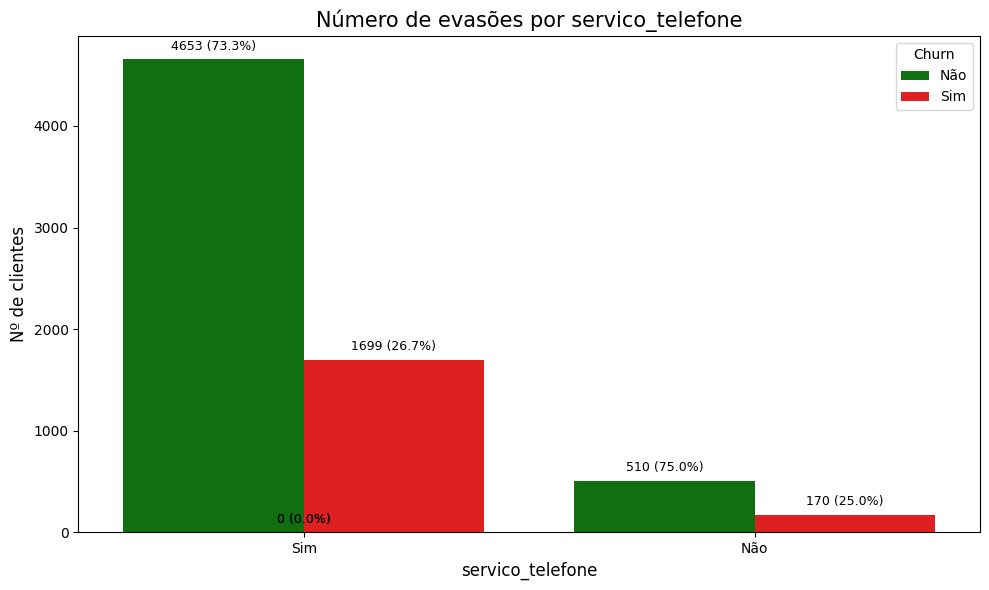

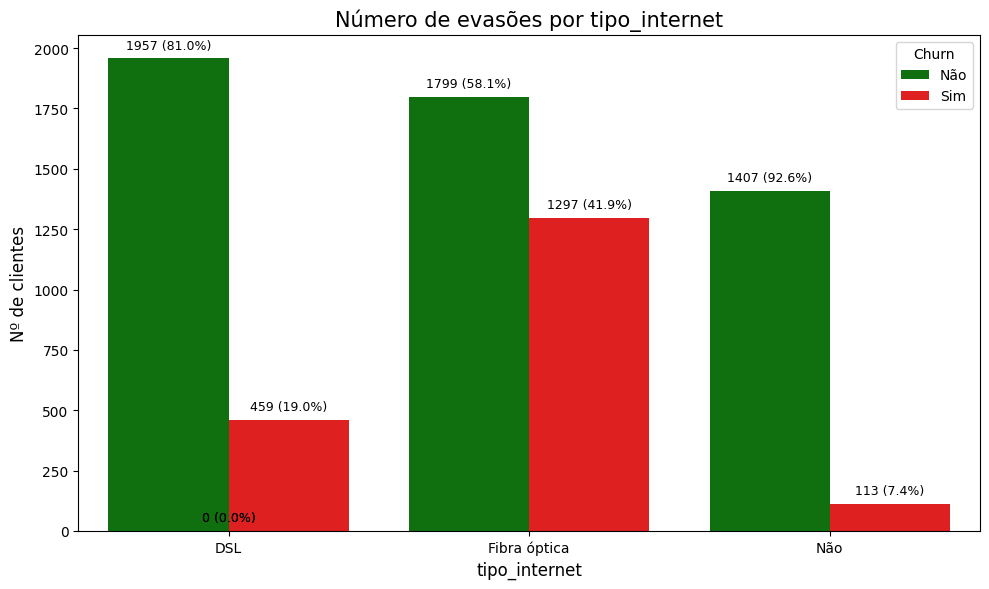

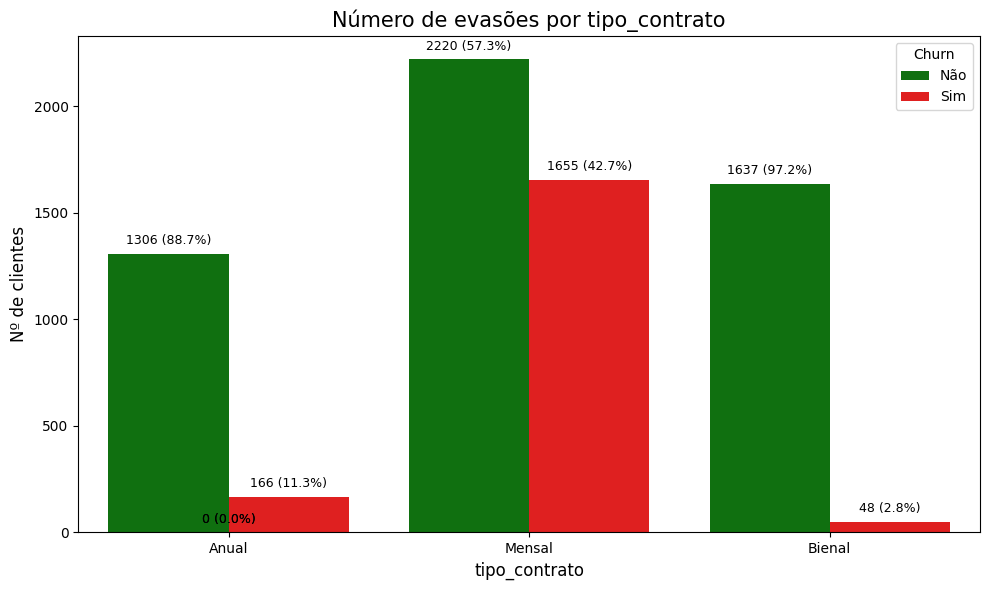

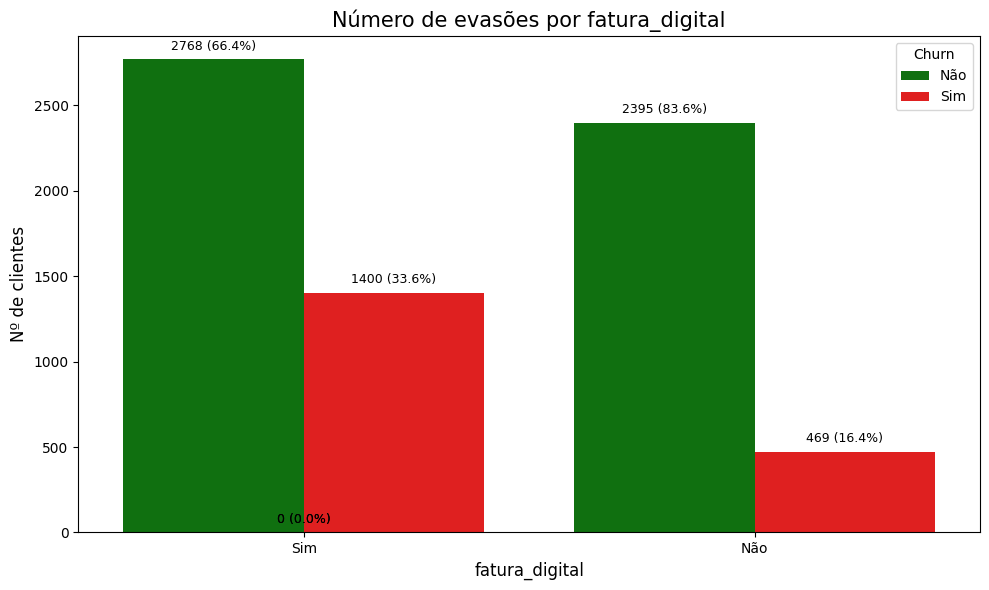

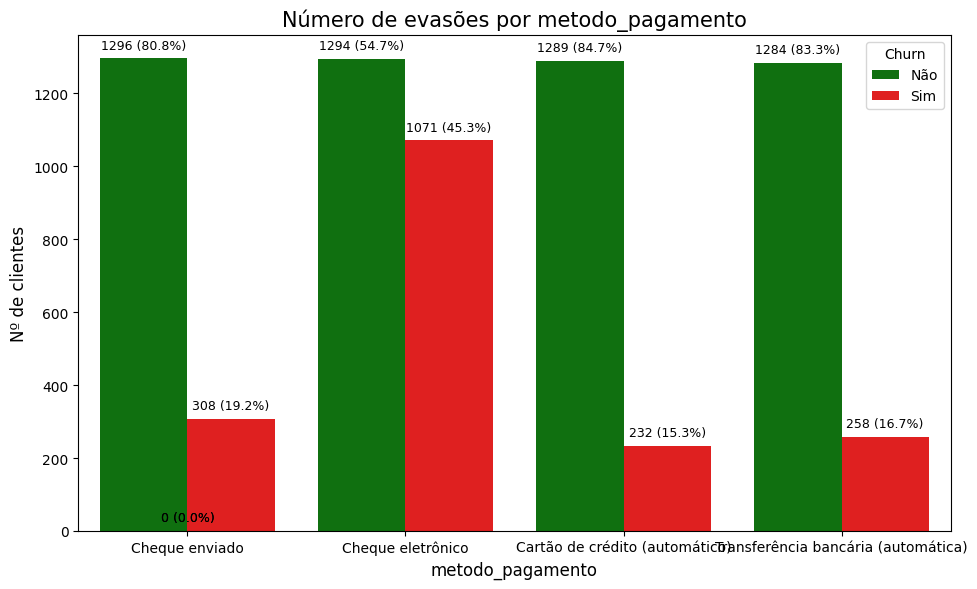

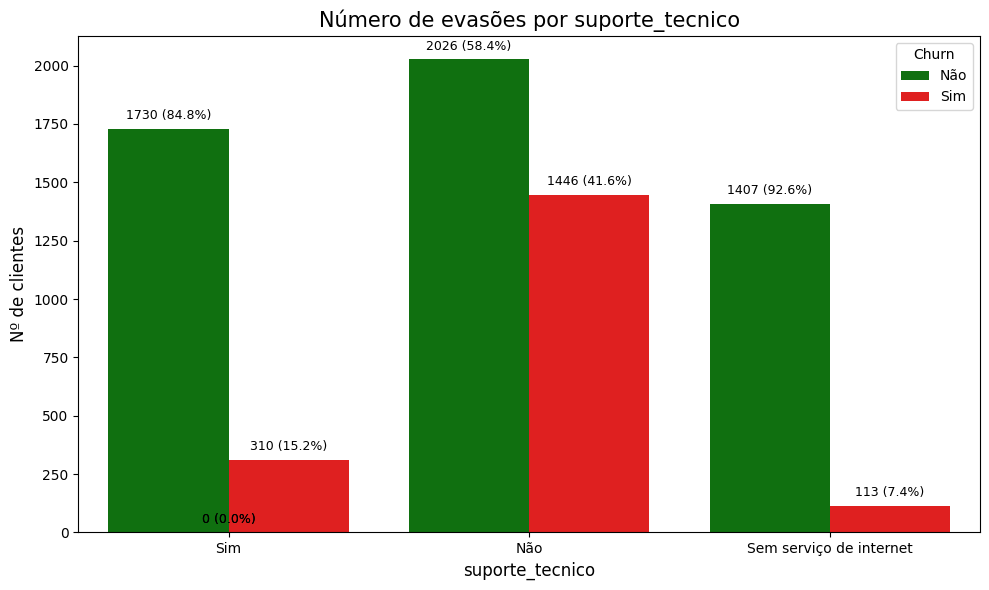

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

variaveis_categoricas = ['genero', 'tem +60', 'possui_parceiro',
       'possui_dependentes', 'servico_telefone', 'tipo_internet', 'tipo_contrato', 'fatura_digital',
       'metodo_pagamento','suporte_tecnico']

# Removido sns.set(rc = {'figure.figsize':(25,20)}) pois os gráficos serão exibidos um abaixo do outro

for var in variaveis_categoricas:
    plt.figure(figsize=(10, 6)) # Cria uma nova figura para cada plot
    ax = sns.countplot(data = df,
                    x = var,
                    hue = 'Churn',
                    palette = {'Não': 'green', 'Sim': 'red'}
                    )

    ax.set_title(f'Número de evasões por {var}', fontsize = 15)
    ax.set_ylabel('Nº de clientes', fontsize = 12)
    ax.set_xlabel(var, fontsize = 12)

    # Calcula as contagens totais para cada categoria principal (eixo x)
    total_counts_per_x_category = df[var].value_counts()

    # Adiciona rótulos de dados com contagem e porcentagem
    for p in ax.patches:
        height = p.get_height()

        # Encontra a categoria do eixo x correspondente à barra atual
        # O centro da barra (p.get_x() + p.get_width() / 2) é arredondado para corresponder ao índice da tick no eixo x
        x_label_index = round(p.get_x() + p.get_width() / 2)
        current_x_category = ax.get_xticklabels()[x_label_index].get_text()

        # Obtém o total para esta categoria do eixo x
        total = total_counts_per_x_category.get(current_x_category, 0)

        if total > 0:
            percentage = (height / total) * 100
            annotation_text = f'{int(height)} ({percentage:.1f}%)'
        else:
            annotation_text = str(int(height)) # Caso o total seja zero (não deve ocorrer se height > 0)

        ax.annotate(annotation_text,
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                    textcoords='offset points') # Desloca o texto ligeiramente acima da barra

    plt.tight_layout() # Ajusta o layout para evitar sobreposição de rótulos
    plt.show() # Exibe cada plot individualmente

5. Distribuição por Valor Mensal

In [65]:
import plotly.express as px

px.box(df, x = 'Churn', y = 'valor_mensal', color = 'Churn')

In [66]:
import plotly.express as px

# Box plot for 'total_cobrado' vs 'Churn'
fig_total_cobrado = px.box(df, x = 'Churn', y = 'total_cobrado', color = 'Churn', title='Distribuição do Total Cobrado por Churn')
fig_total_cobrado.show()

# Box plot for 'contas_diarias' vs 'Churn'
fig_contas_diarias = px.box(df, x = 'Churn', y = 'contas_diarias', color = 'Churn', title='Distribuição das Contas Diárias por Churn')
fig_contas_diarias.show()

In [67]:
import plotly.express as px

fig_tempo_contrato = px.box(df, x='Churn', y='tempo_contrato', color='Churn', title='Distribuição do Tempo de Contrato por Churn')
fig_tempo_contrato.show()

Distribuição de Churn por Tempo de Contraro

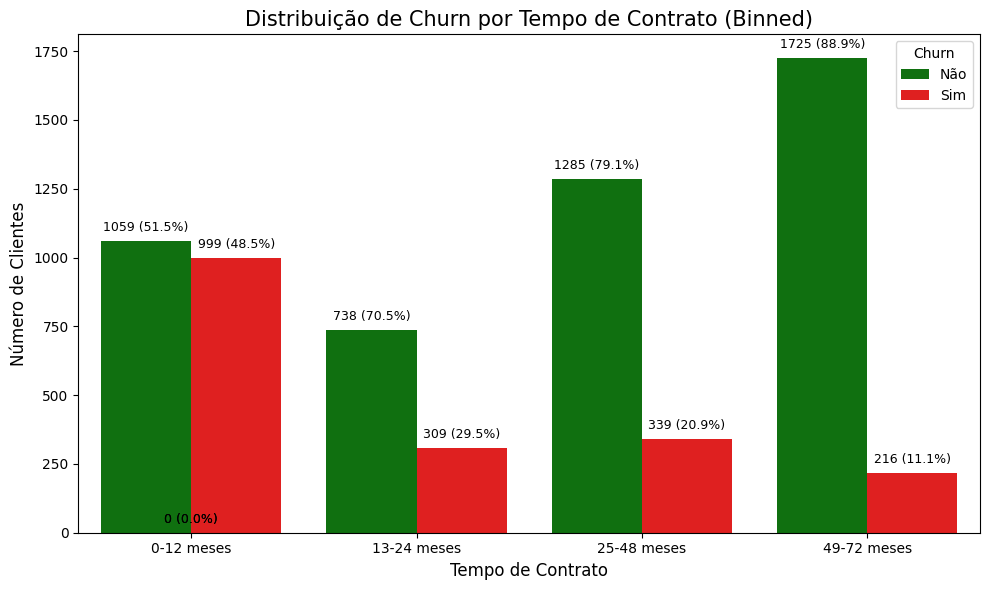

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Criar bins para 'tempo_contrato'
bins = [0, 12, 24, 48, 72]
labels = ['0-12 meses', '13-24 meses', '25-48 meses', '49-72 meses']
df['tempo_contrato_binned'] = pd.cut(df['tempo_contrato'], bins=bins, labels=labels, right=False, include_lowest=True)

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='tempo_contrato_binned', hue='Churn', palette={'Não': 'green', 'Sim': 'red'})
plt.title('Distribuição de Churn por Tempo de Contrato (Binned)', fontsize=15)
plt.xlabel('Tempo de Contrato', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)
plt.legend(title='Churn', labels=['Não', 'Sim'], loc='upper right')

# Adicionar anotações com contagem e porcentagem
total_binned_counts = df['tempo_contrato_binned'].value_counts()

for p in ax.patches:
    height = p.get_height()

    # Encontra a categoria do eixo x correspondente à barra atual
    x_label_index = round(p.get_x() + p.get_width() / 2)
    current_x_category = ax.get_xticklabels()[x_label_index].get_text()

    total = total_binned_counts.get(current_x_category, 0)

    if total > 0:
        percentage = (height / total) * 100
        annotation_text = f'{int(height)} ({percentage:.1f}%)'
    else:
        annotation_text = str(int(height))

    ax.annotate(annotation_text,
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

#📄Relatorio Final

#**Telecom X - Análise de Evasão de Clientes(churn)**

#Introdução
O relatório apresenta uma análise detalhada sobre a evação de clientes na empresa de telelecomunicação a Telecom X, que vem sofrendo auto índice de evasão de clientes e não conseguem descobrir o que está ocorrendo.
Através da análise exploratória dos dados(EDA), buscamos identificar comportamentos e fatores que influenciam no cancelamento do serviço.

#Objetivo

* Identificar comportamentos associados ao churn
* Analisar os perfis de clientes que mais cancelam
* Identificar serviços que podem contribuir para que os clientes cancelem
* Formecer insights para reduzir o churn

#Extração

Importação dos dados no formato Jason

#Limpeza e tratamento de dados

* Padronização de variáveis categóricas(Sim/Não)
* Tratamento de valores inconsistentes e ausentes
* Padronização das colunas para o português
* Alterando a coluna 'account.Charges.Total' para o tipo float
* Criação da variável contas diárias

#Análise Exploratória de Dados

A análise exploratória e gráficos gerados( barras e boxplot), foram baseados na Distribuição Geral da Evasão de clientes, Churn por variáveis categóricas e Churn por variáveis numéricas.



1 - Distribuição Geral da Evasão de cliente

Conforme gráfico de barras, 73,4% dos clientes cancelam o serviço enquanto 26,6 não cancelam o serviço. Embora a maioria não cancele, ainda assim a churn é alto.

2 - Variáveis Categóricas

**Número de evasão x tipo de internet**

Tipo de internet fibra óptica tem um churn de 41,9% em relação as outras




**Número de evasão x suporte técnico**

Sem suporte técnico tem um churn de 41,6%.



3- Variáveis Numéricas

**Distribuição de Churn x tipo de contrato**

A modalidade de contrato mensal tem um churn de 42,7% em relação ao anual e bienal.

**Distribuição de Churn x tempo de contrato**

A concentração de churn é de 48,5%, no primeiro de 0 à 12 meses, ou seja os novos clientes tendem a cancelarem o serviço logo nos primeiros meses.

#Insigths

* Clientes com contratos mensais apresentam maior churn, isso pode ser em decorrência de valores altos.

* Clientes com menor tempo de permanência cancelam mais, isso indica que não teve um ótimo onboarding ou um trabalho de fidelização com o cliente.

* Cliente com internet do tipo fibra óptica, pode indicar que a qualidade da conexão né é boa.

* Cliente sem suporte técnicos cancelam mais, isso pode indica que não há um suporte básico de forma gratuita.

# Recomendações

- Investigar a qualidade da conexão do tipo fibra óptica.
- Contrato mensais, incentivar o cliente para migrar para os planos bienais ou anuais, cujo valor á mais barato.
- Realizar um onboarding e acompanhar o cliente nos primeiros meses de contrato, para que tenha um ótima experiência.
- Avaliar a possibilidade de criar um pacote básico de suporte, para problemas simples.


#Conclusões
Os resultados das análises realizadas e recomendações, podem ser utilizados como base para estratégias de retenção e até desenvolvimento de modelos preditivos de churn.